Reference Notebook

https://www.kaggle.com/code/cdeotte/titanic-wcg-xgboost-0-84688#Comparison-with-Mega-Model

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from xgboost import XGBClassifier
from xgboost import plot_importance

c:\Users\Nutzer\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:35: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.2)
  import scipy.sparse


## Load Data

In [2]:
train = pd.read_csv("data/train_kaggle.csv")
test = pd.read_csv("data/test_kaggle.csv")


In [3]:
data = pd.concat([train, test], axis=0)
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


## Feature Engineering

In [4]:
# Create Title column
data["Title"] = "man"

# Passengers with "Master" in their name are classified as "boy"
data.loc[data["Name"].str.contains("Master"), "Title"] = "boy"

# Female passengers are classified as "woman"
data.loc[data["Sex"] == "female", "Title"] = "woman"


In [5]:
# TicketFreq: count occurrences of each ticket number
data["TicketFreq"] = data.groupby("Ticket")["Ticket"].transform("count")

# Family size
data["FamilySize"] = data["SibSp"] + data["Parch"] + 1


## About WCG Variables

## Create Woman-Child-Group

Create groups using ticket and other information  
Calculate the survival rate for each group  


- If all women and boys in the group survived, boys are predicted to survive
- If all women and boys in the group died, women are predicted to have died


In [6]:
# Create Surname column
# Extract the part before "," in the name as the Surname
data["Surname"] = data["Name"].apply(lambda x: x.split(",")[0])

# Create GroupId
# Combine surname, Pclass, ticket, fare, and embarkation port to identify the same group
data["GroupId"] = data["Surname"] + "-" + data["Pclass"].astype(str) + data["Ticket"].str[:-1] + "X" + "-" + data["Fare"].astype(str) + "-" + data["Embarked"].astype(str)
# data["Ticket"].str[:-1] + "X": removes the last character of the ticket number and appends "X"
# Replacing the last character with "X" allows grouping even when ticket numbers differ slightly at the end

# Set GroupId to "noGroup" for men
data.loc[data["Title"] == "man", "GroupId"] = "noGroup"


# Count the number of members in each GroupId
data["GroupFreq"] = data.groupby("GroupId")["GroupId"].transform("count")
data.loc[data["GroupFreq"] <= 1, "GroupId"] = "noGroup"


In [7]:
# Count the number of woman-child groups
# Men belong to noGroup, so we count only women and children groups
# Subtract 1 to exclude "noGroup"
unique_groups_count = data["GroupId"].nunique() - 1
print(unique_groups_count, "woman-child-groups")


80 woman-child-groups


In [8]:
# Create a TicketId column separate from GroupId
data['TicketId'] = data['Pclass'].astype(str) + '-' + data['Ticket'].str[:-1] + 'X' + '-' + data['Fare'].astype(str) + '-' + data['Embarked'].astype(str)


In [9]:
c = 0  # Counter for passengers newly added to a group

# Women and children not yet assigned to a group (GroupId == "noGroup")
for _, row in data[(data["Title"] != "man") & (data["GroupId"] == "noGroup")].iterrows():
    matching_group = data[data["TicketId"] == row["TicketId"]]["GroupId"].iloc[0]

    # Update GroupId using PassengerId
    data.loc[data["PassengerId"] == row["PassengerId"], "GroupId"] = matching_group

    if matching_group != "noGroup":
        c += 1

print(c, "passengers added to groups")


9 passengers added to groups


Apply group survival rates to the test data  
Passengers in the same group are assigned the same survival rate  


In [10]:
# Calculate survival rate per group in the training data
data.loc[data["PassengerId"] <= 891, "GroupSurvived"] = data.loc[data["PassengerId"] <= 891].groupby("GroupId")["Survived"].transform("mean")
data.loc[data["PassengerId"] <= 891, "GroupSurvived"].isna().sum()
# If missing values are 0, it's OK


np.int64(0)

In [11]:
# Create group_survived_dict from training data, excluding noGroup
group_survived_dict = data.loc[(data["PassengerId"] <= 891) & (data["GroupId"] != "noGroup")].set_index("GroupId")["GroupSurvived"].to_dict()
group_survived_dict


{'Palsson-334990X-21.075-S': 0.0,
 'Johnson-334774X-11.1333-S': 1.0,
 'Sandstrom-3PP 954X-16.7-S': 1.0,
 'Rice-338265X-29.125-Q': 0.0,
 'Vander Planke-334576X-18.0-S': 0.0,
 'Asplund-334707X-31.3875-S': 0.75,
 'Nicola-Yarred-3265X-11.2417-C': 1.0,
 'Laroche-2SC/Paris 212X-41.5792-C': 1.0,
 'Panula-3310129X-39.6875-S': 0.0,
 'West-2C.A. 3465X-27.75-S': 1.0,
 'Goodwin-3CA 214X-46.9-S': 0.0,
 'Skoog-334708X-27.9-S': 0.0,
 'Moubarek-3266X-15.2458-C': 1.0,
 'Caldwell-224873X-29.0-S': 1.0,
 'Fortune-11995X-263.0-S': 1.0,
 'Doling-223191X-23.0-S': 1.0,
 'Zabour-3266X-14.4542-C': 0.0,
 'Jussila-3413X-9.825-S': 0.0,
 'Andersson-334708X-31.275-S': 0.0,
 'Peter-3266X-22.3583-C': 1.0,
 'Boulos-3267X-15.2458-C': 0.0,
 'Ford-3W./C. 660X-34.375-S': 0.0,
 'Sage-3CA. 234X-69.55-S': 0.0,
 'Watt-2C.A. 3359X-15.75-S': 1.0,
 'Goldsmith-336329X-20.525-S': 1.0,
 'Lefebre-3413X-25.4667-S': 0.0,
 'Becker-223013X-39.0-S': 1.0,
 'Kink-Heilmann-331515X-22.025-S': 1.0,
 'Navratil-223008X-26.0-S': 1.0,
 'Strom-3347

In [12]:
# Assign GroupSurvived based on GroupId using the dictionary
for groupid in group_survived_dict.keys():
    data.loc[(data["PassengerId"] >= 892) & (data["GroupId"] == groupid), "GroupSurvived"] = group_survived_dict[groupid]


In [13]:
# Groups with unknown survival rate
# Class 3 passengers have lower survival rates
data.loc[(data["GroupSurvived"].isna()) & (data["Pclass"] == 3), "GroupSurvived"] = 0
data.loc[(data["GroupSurvived"].isna()) & (data["Pclass"] != 3), "GroupSurvived"] = 1


In [14]:
# Survival prediction based on Woman-Child-Group (WCG)
# Initialize: everyone starts as "will not survive" (WCG=0)
data["WCG"] = 0
# All women start as "will survive" (WCG=1)
data.loc[data["Sex"] == "female", "WCG"] = 1


# Women in groups where all members died (GroupSurvived == 0) are predicted to die
data.loc[(data["Title"] == "woman") & (data["GroupSurvived"] == 0), "WCG"] = 0
# Boys in groups where all members survived (GroupSurvived == 1) are predicted to survive
data.loc[(data["Title"] == "boy") & (data["GroupSurvived"] == 1), "WCG"] = 1

# Number of boys predicted to survive
boys_predicted_to_live = data[(data["Sex"] == "male") & (data["WCG"] == 1) & (data["PassengerId"] > 891)]
print(len(boys_predicted_to_live), "boys predicted to survive")

# Number of women predicted to die
females_predicted_to_die = data[(data['Sex'] == "female") & (data['WCG'] == 0) & (data['PassengerId'] > 891)]
print(len(females_predicted_to_die), "women predicted to die")


8 boys predicted to survive
61 women predicted to die


## End of WCG Section

In [15]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'TicketFreq',
       'FamilySize', 'Surname', 'GroupId', 'GroupFreq', 'TicketId',
       'GroupSurvived', 'WCG'],
      dtype='object')

In [16]:
# Convert Pclass to string type for one-hot encoding
data["Pclass"] = data["Pclass"].astype(str)

# One-hot encoding
temp = pd.get_dummies(data[["Sex", "Pclass"]], drop_first=False)
temp["PassengerId"] = data["PassengerId"]
data = pd.merge(data, temp)


In [17]:
# Split data back into train and test sets
train = data.loc[data["PassengerId"] <= 891]
test = data.loc[data["PassengerId"] >= 892]


In [18]:
# Verify the data split
train


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,GroupId,GroupFreq,TicketId,GroupSurvived,WCG,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,noGroup,782,3-A/5 2117X-7.25-S,0.337415,0,False,True,False,False,True
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,noGroup,1,1-PC 1759X-71.2833-C,0.337415,1,True,False,True,False,False
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,noGroup,1,3-STON/O2. 310128X-7.925-S,0.337415,1,True,False,False,False,True
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,noGroup,1,1-11380X-53.1-S,0.337415,1,True,False,True,False,False
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,noGroup,782,3-37345X-8.05-S,0.337415,0,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0.0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,...,noGroup,782,2-21153X-13.0-S,0.337415,0,False,True,False,True,False
887,888,1.0,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,...,noGroup,1,1-11205X-30.0-S,0.337415,1,True,False,True,False,False
888,889,0.0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,...,Johnston-3W./C. 660X-23.45-S,3,3-W./C. 660X-23.45-S,0.000000,0,True,False,False,False,True
889,890,1.0,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,...,noGroup,782,1-11136X-30.0-C,0.337415,0,False,True,True,False,False


In [19]:
# Display current feature columns
train.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'TicketFreq',
       'FamilySize', 'Surname', 'GroupId', 'GroupFreq', 'TicketId',
       'GroupSurvived', 'WCG', 'Sex_female', 'Sex_male', 'Pclass_1',
       'Pclass_2', 'Pclass_3'],
      dtype='object')

In [20]:
# Drop unnecessary columns
X_train = train.drop(columns=["PassengerId", "Pclass", 'Name', "Age", 'SibSp', 'Parch', "Ticket", "Cabin", "Title", "Surname", "GroupId", "GroupFreq", "TicketId", "GroupSurvived", "Survived", "Sex", "Embarked"])
X_test = test.drop(columns=["PassengerId", "Pclass", 'Name', "Age", 'SibSp', 'Parch', "Ticket", "Cabin", "Title", "Surname", "GroupId", "GroupFreq", "TicketId", "GroupSurvived", "Survived", "Sex", "Embarked"])


In [21]:
# Display feature matrix
X_train


,Fare,TicketFreq,FamilySize,WCG,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3
0,7.2500,1,2,0,False,True,False,False,True
1,71.2833,2,2,1,True,False,True,False,False
2,7.9250,1,1,1,True,False,False,False,True
3,53.1000,2,2,1,True,False,True,False,False
4,8.0500,1,1,0,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...
886,13.0000,1,1,0,False,True,False,True,False
887,30.0000,1,1,1,True,False,True,False,False
888,23.4500,4,4,0,True,False,False,False,True
889,30.0000,1,1,0,False,True,True,False,False


In [22]:
# Convert target variable to integer
y_train = train["Survived"].astype(int)


## Prediction with XGBoost

In [23]:
xgb = XGBClassifier(max_depth=3, learning_rate=0.1, n_estimators=80)
xgb.fit(X_train, y_train)
y_test = xgb.predict(X_test)
y_test

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [24]:
test['Survived'] = y_test.astype(int)


C:\Users\Nutzer\AppData\Local\Temp\ipykernel_21412\812078078.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Survived'] = y_test.astype(int)


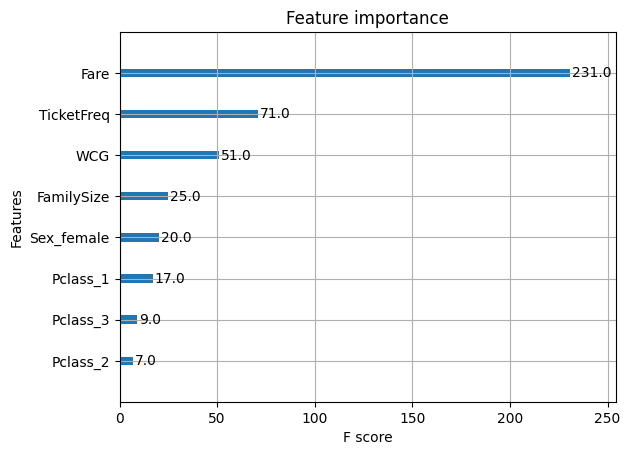

In [25]:
# Plot feature importance
plot_importance(xgb)
plt.show()


## Submission

In [26]:
submission = test[["PassengerId","Survived"]]
submission = submission.reset_index(drop=True)
submission = pd.DataFrame(submission)
submission


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [27]:
submission.to_csv("submissions/submission.csv", index=False)
